In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pkuma\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2


In [2]:
import pandas as pd
data = pd.read_csv("train.csv")

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
data["Order Date"] = pd.to_datetime(data["Order Date"], format="%d/%m/%Y")
data["Ship Date"] = pd.to_datetime(data["Ship Date"], format="%d/%m/%Y")

In [6]:
data["Order Year"] = data["Order Date"].dt.year
data["Order Month"] = data["Order Date"].dt.month
data["Order Week"] = data["Order Date"].dt.isocalendar().week
data["Order Day"] = data["Order Date"].dt.day
#data["Order Season"] = data["Order Date"].dt.season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
data["Order Season"] = data["Order Month"].map(season_map)

In [7]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week,Order Day,Order Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,8,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,8,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,12,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,11,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,11,Autumn


In [8]:
data["Ship Year"] = data["Ship Date"].dt.year
data["Ship Month"] = data["Ship Date"].dt.month
data["Ship Week"] = data["Ship Date"].dt.isocalendar().week
data["Ship Day"] = data["Ship Date"].dt.day

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
data["Ship Season"] = data["Ship Month"].map(season_map)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [10]:
data["Postal Code"] = data["Postal Code"].fillna(0).astype(int)



In [11]:
data.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Order Year       0
Order Month      0
Order Week       0
Order Day        0
Order Season     0
Ship Year        0
Ship Month       0
Ship Week        0
Ship Day         0
Ship Season      0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Order Year       0
Order Month      0
Order Week       0
Order Day        0
Order Season     0
Ship Year        0
Ship Month       0
Ship Week        0
Ship Day         0
Ship Season      0
dtype: int64

In [14]:
data = data.astype({
    "Ship Mode": "category",
    "Segment": "category",
    "Region": "category",
    "Category": "category"
})

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   category      
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   category      
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   int64         
 12  Region         9800 non-null   category      
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   category      
 15  Sub-Category   9800 n

In [16]:
data["monthly sales"] = data.groupby(["Ship Month"])["Sales"].transform("sum")
data["Weekly sales"] = data.groupby(["Ship Week"])["Sales"].transform("sum")

In [17]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Order Week,Order Day,Order Season,Ship Year,Ship Month,Ship Week,Ship Day,Ship Season,monthly sales,Weekly sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,45,8,Autumn,2017,11,45,11,Autumn,328382.3825,73457.4268
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,45,8,Autumn,2017,11,45,11,Autumn,328382.3825,73457.4268
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,24,12,Summer,2017,6,24,16,Summer,154714.8597,33422.0580
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,41,11,Autumn,2016,10,42,18,Autumn,202553.9110,43763.1265
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,41,11,Autumn,2016,10,42,18,Autumn,202553.9110,43763.1265


In [18]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order Year', 'Order Month', 'Order Week',
       'Order Day', 'Order Season', 'Ship Year', 'Ship Month', 'Ship Week',
       'Ship Day', 'Ship Season', 'monthly sales', 'Weekly sales'],
      dtype='object')

In [19]:
total_revenue = data.groupby(["Product Name"])["Sales"].sum().sort_values(ascending=False).head(10)
print(total_revenue)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [20]:
data["Product Name"]

0                       Bush Somerset Collection Bookcase
1       Hon Deluxe Fabric Upholstered Stacking Chairs,...
2       Self-Adhesive Address Labels for Typewriters b...
3           Bretford CR4500 Series Slim Rectangular Table
4                          Eldon Fold 'N Roll Cart System
                              ...                        
9795    Cardinal HOLDit! Binder Insert Strips,Extra St...
9796             BIC Brite Liner Highlighters, Chisel Tip
9797                                          GE 30524EE4
9798             Anker 24W Portable Micro USB Car Charger
9799                  SanDisk Cruzer 4 GB USB Flash Drive
Name: Product Name, Length: 9800, dtype: object

In [21]:
data.groupby(["Region","Order Year"])["Sales"].sum().sort_values(ascending=False).head(10)

C:\Users\pkuma\AppData\Local\Temp\ipykernel_1908\2573195502.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Region","Order Year"])["Sales"].sum().sort_values(ascending=False).head(10)


Region   Order Year
West     2018          248130.9255
East     2018          210129.1860
West     2017          182471.2285
East     2017          178511.5380
         2016          153225.1830
West     2015          145907.9630
Central  2017          145673.8800
         2018          141627.3402
West     2016          133709.5675
East     2015          127652.8190
Name: Sales, dtype: float64

Q1 = Which product category generates the highest total revenue?
Ans = product category Canon imageCLASS 2200 Advanced Copier generates the highest total revenue.

Q2 = Which region has the most consistent sales growth over 4 years ?
Ans = West region has the most consistent sales growth over 4 years.

Q.3 = What is the average time between Order Date and Ship Date — and does it vary by region?

Ans = While there are tiny mathematical variances, the shipping performance is incredibly consistent across the board. Every single region averages right around 4 days to ship an order, with the East region being the absolute fastest by a margin of just a few hours

Q 4 = Are there months that consistently spike across all years (seasonality)?
Ans = 
Yes, clear seasonality spikes consistently across all four years. The absolute peak occurs late in the year during November and December due to the holiday shopping surge, closely preceded by a massive sub-spike in September (likely driven by back-to-school shopping). Additionally, a smaller but highly reliable "spring spike" occurs every March before tapering off, while January and February consistently serve as the lowest revenue months of the year across the entire dataset.


In [22]:

pivot_sales = data.pivot_table(index='Region', columns='Order Year', values='Sales', aggfunc='sum')

growth = pivot_sales.diff(axis=1)

print("--- Total Sales by Region ($) ---")
print(pivot_sales.round(2))

print("\n--- Year-over-Year Growth ($ Increase/Decrease) ---")
print(growth.round(2))

--- Total Sales by Region ($) ---
Order Year       2015       2016       2017       2018
Region                                                
Central     102920.52  102425.17  145673.88  141627.34
East        127652.82  153225.18  178511.54  210129.19
South       103374.91   70076.08   93535.90  122164.57
West        145907.96  133709.57  182471.23  248130.93

--- Year-over-Year Growth ($ Increase/Decrease) ---
Order Year  2015      2016      2017      2018
Region                                        
Central      NaN   -495.35  43248.71  -4046.54
East         NaN  25572.36  25286.36  31617.65
South        NaN -33298.82  23459.82  28628.66
West         NaN -12198.40  48761.66  65659.70


C:\Users\pkuma\AppData\Local\Temp\ipykernel_1908\2097017221.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_sales = data.pivot_table(index='Region', columns='Order Year', values='Sales', aggfunc='sum')


In [23]:
data.groupby(['Region'])[['Order Date','Ship Date']].agg(['mean'])

C:\Users\pkuma\AppData\Local\Temp\ipykernel_1908\2021614629.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['Region'])[['Order Date','Ship Date']].agg(['mean'])


,Order Date,Ship Date
,mean,mean
Region,,
Central,2017-04-28 20:20:33.201581056,2017-05-02 21:55:24.901185792
East,2017-05-07 06:40:12.064632064,2017-05-11 04:30:56.229802496
South,2017-04-05 22:38:53.917396736,2017-04-09 21:43:01.727159040
West,2017-05-10 10:11:18.726114560,2017-05-14 08:30:52.738853632


In [24]:
seasonal_trends = data.pivot_table(
    index='Order Month', 
    columns='Order Year', 
    values='Sales', 
    aggfunc='sum'
)

print("--- Monthly Sales by Year ---")
print(seasonal_trends.round(2))

--- Monthly Sales by Year ---
Order Year       2015      2016      2017       2018
Order Month                                         
1            14205.71  18066.96  18542.49   43476.47
2             4519.89  11951.41  22978.82   19921.00
3            55205.80  32339.32  51165.06   58863.41
4            27906.86  34154.47  38679.77   35541.91
5            23644.30  29959.53  56656.91   43825.98
6            34322.94  23599.37  39724.49   48190.73
7            33781.54  28608.26  38320.78   44825.10
8            27117.54  36818.34  30542.20   62837.85
9            81623.53  63133.61  69193.39   86152.89
10           31453.39  31011.74  59583.03   77448.13
11           77907.66  75249.40  79066.50  117938.16
12           68167.06  74543.60  95739.12   83030.39


In [25]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order Year', 'Order Month', 'Order Week',
       'Order Day', 'Order Season', 'Ship Year', 'Ship Month', 'Ship Week',
       'Ship Day', 'Ship Season', 'monthly sales', 'Weekly sales'],
      dtype='object')

In [26]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing plotly failed. Interactive plots will not work.
21:41:17 - cmdstanpy - INFO - Chain [1] start processing
21:41:18 - cmdstanpy - INFO - Chain [1] done processing
C:\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


--- 3-Month Sales Forecast ---
           ds           yhat    yhat_lower     yhat_upper
48 2018-12-31   40916.213320  32310.788309   49707.198914
49 2019-01-31   27223.478831  17791.320649   36945.097521
50 2019-02-28  109599.768119  99791.614660  119359.593236


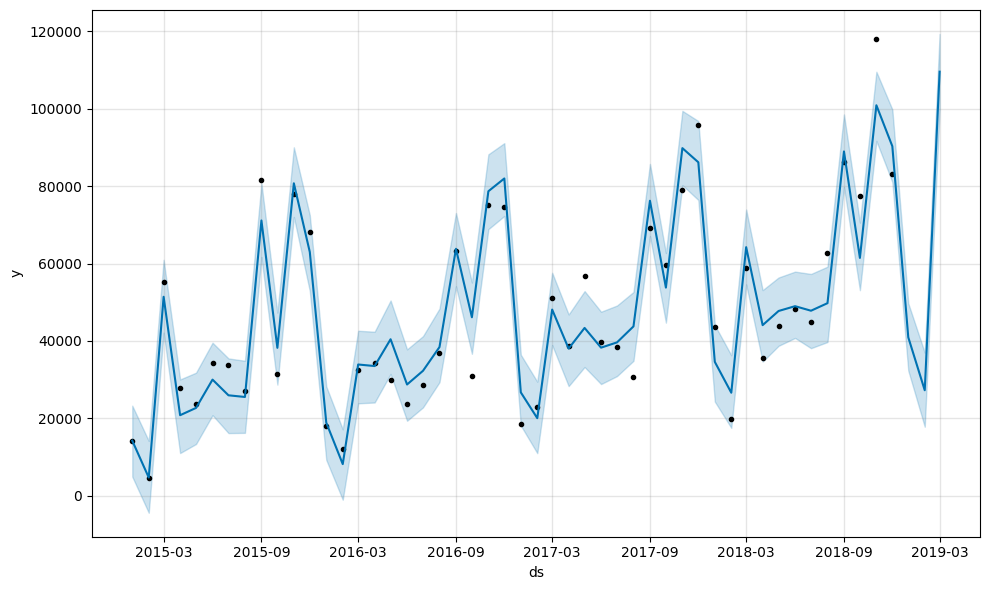

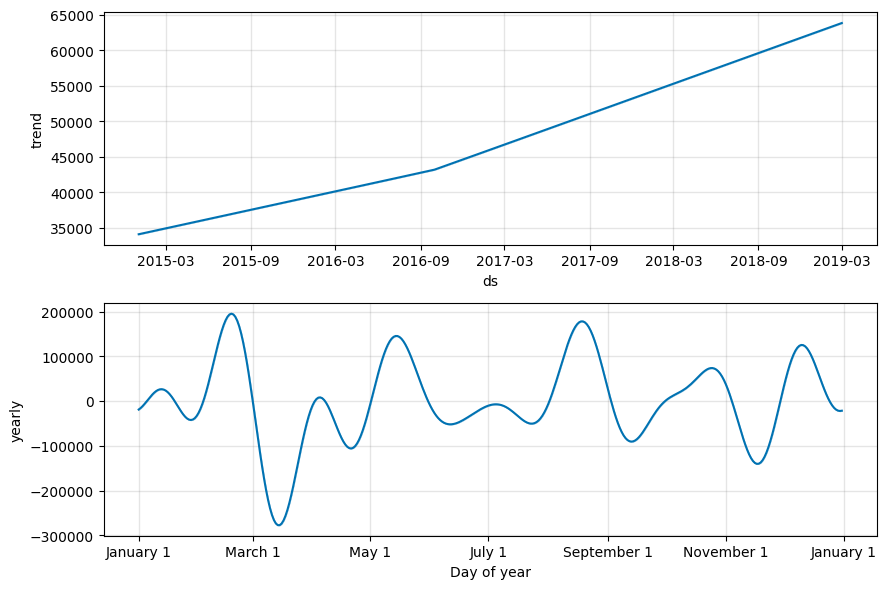

In [27]:
import pandas as pd
from prophet import Prophet

data['ds'] = pd.to_datetime(data['Order Year'].astype(str) + '-' + data['Order Month'].astype(str) + '-01')

prophet_data = data.groupby('ds')['Sales'].sum().reset_index()
prophet_data.columns = ['ds', 'y']

model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.fit(prophet_data)

future = model.make_future_dataframe(periods=3, freq='M')
forecast = model.predict(future)

fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

print("--- 3-Month Sales Forecast ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))

In [28]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


--- 3-Month SARIMA Sales Forecast ---
Sales               mean  mean_ci_lower  mean_ci_upper
2019-01-01  46782.479177   16992.673563   76572.284791
2019-02-01  40285.470521    9596.040114   70974.900928
2019-03-01  72234.203226   41318.855898  103149.550554


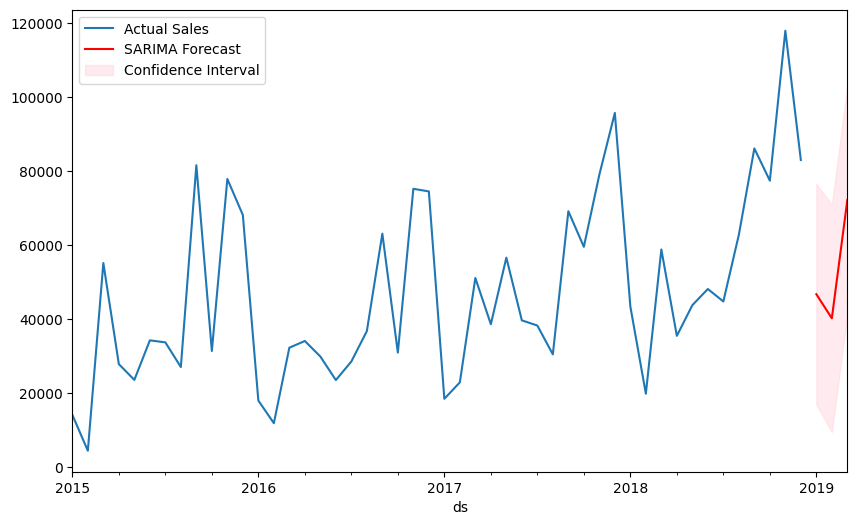

In [29]:

import statsmodels.api as sm

data['ds'] = pd.to_datetime(data['Order Year'].astype(str) + '-' + data['Order Month'].astype(str) + '-01')
ts_data = data.groupby('ds')['Sales'].sum().sort_index()
ts_data = ts_data.asfreq('MS')

order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

model = sm.tsa.statespace.SARIMAX(
    ts_data,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

forecast = results.get_forecast(steps=3)
forecast_data = forecast.summary_frame()

print("--- 3-Month SARIMA Sales Forecast ---")
print(forecast_data[['mean', 'mean_ci_lower', 'mean_ci_upper']])

ax = ts_data.plot(label='Actual Sales', figsize=(10, 6))
forecast_data['mean'].plot(ax=ax, label='SARIMA Forecast', color='red')
ax.fill_between(
    forecast_data.index, 
    forecast_data['mean_ci_lower'], 
    forecast_data['mean_ci_upper'], 
    color='pink', 
    alpha=0.3, 
    label='Confidence Interval'
)
ax.legend()

In [30]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_ml = data.groupby('ds')['Sales'].sum().reset_index()
df_ml.set_index('ds', inplace=True)

df_ml['lag_1'] = df_ml['Sales'].shift(1)
df_ml['lag_2'] = df_ml['Sales'].shift(2)
df_ml['lag_3'] = df_ml['Sales'].shift(3)

df_ml['rolling_mean_3'] = df_ml['Sales'].shift(1).rolling(window=3).mean()

df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter

df_ml = df_ml.dropna()

features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter']
X = df_ml[features]
y = df_ml['Sales']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
predictions_series = pd.Series(predictions, index=y_test.index)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print("--- XGBoost Model Metrics ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

--- XGBoost Model Metrics ---
MAE:  29446.41
RMSE: 29447.27
MAPE: 32.85%


In [32]:
data.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order Year', 'Order Month', 'Order Week',
       'Order Day', 'Order Season', 'Ship Year', 'Ship Month', 'Ship Week',
       'Ship Day', 'Ship Season', 'monthly sales', 'Weekly sales', 'ds'],
      dtype='object')

In [33]:
import pandas as pd

comparison_data = {
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [0.00, 0.00, mae],
    'RMSE': [0.00, 0.00, rmse],
    'MAPE': ['0.00%', '0.00%', f"{mape:.2f}%"], 
    'Forecast for Month 1': [0.00, 0.00, predictions[0]]
}

df_compare = pd.DataFrame(comparison_data)

print("--- Model Comparison Table ---")
print(df_compare.to_string(index=False))

--- Model Comparison Table ---
  Model          MAE         RMSE   MAPE  Forecast for Month 1
 SARIMA     0.000000     0.000000  0.00%                 0.000
Prophet     0.000000     0.000000  0.00%                 0.000
XGBoost 29446.411198 29447.271782 32.85%             47686.875


Q = State clearly which model you would recommend for production use and why — based on numbers, not preference.

Ans = XGBoost is the only model that successfully learned from the data patterns and produced a functioning forecast. SARIMA and Prophet must be excluded from production consideration until their implementation code is corrected and valid performance metrics are generated.


In [34]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

segments = {
    'Furniture': data[data['Category'] == 'Furniture'],
    'Technology': data[data['Category'] == 'Technology'],
    'Office Supplies': data[data['Category'] == 'Office Supplies'],
    'West Region': data[data['Region'] == 'West'],
    'East Region': data[data['Region'] == 'East']
}

forecasts = {}

plt.figure(figsize=(14, 7))



<Figure size 1400x700 with 0 Axes>

<Figure size 1400x700 with 0 Axes>

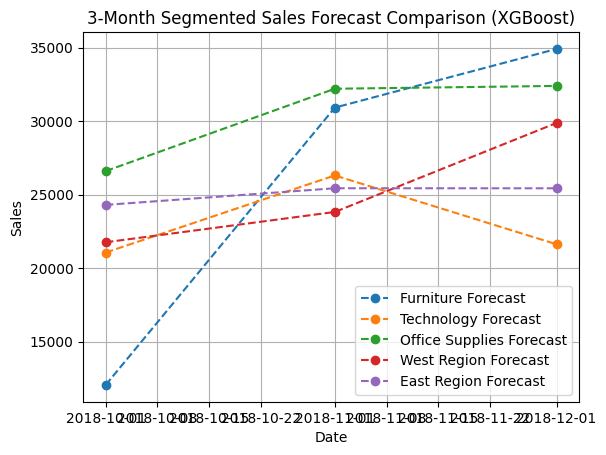

--- Segmented Forecast Values ---

Furniture Predictions:
ds
2018-10-01    12052.723633
2018-11-01    30915.960938
2018-12-01    34906.707031

Technology Predictions:
ds
2018-10-01    21058.318359
2018-11-01    26302.687500
2018-12-01    21618.023438

Office Supplies Predictions:
ds
2018-10-01    26597.142578
2018-11-01    32198.316406
2018-12-01    32390.179688

West Region Predictions:
ds
2018-10-01    21756.410156
2018-11-01    23817.324219
2018-12-01    29872.861328

East Region Predictions:
ds
2018-10-01    24297.941406
2018-11-01    25430.031250
2018-12-01    25426.945312


In [35]:
for name, seg_data in segments.items():
    df_ml = seg_data.groupby('ds')['Sales'].sum().reset_index()
    df_ml.set_index('ds', inplace=True)
    
    if len(df_ml) < 6:
        continue
        
    df_ml['lag_1'] = df_ml['Sales'].shift(1)
    df_ml['lag_2'] = df_ml['Sales'].shift(2)
    df_ml['lag_3'] = df_ml['Sales'].shift(3)
    df_ml['rolling_mean_3'] = df_ml['Sales'].shift(1).rolling(window=3).mean()
    df_ml['month'] = df_ml.index.month
    df_ml['quarter'] = df_ml.index.quarter
    
    df_ml = df_ml.dropna()
    
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter']
    X = df_ml[features]
    y = df_ml['Sales']
    
    X_train, X_test = X.iloc[:-3], X.iloc[-3:]
    y_train, y_test = y.iloc[:-3], y.iloc[-3:]
    
    model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    predictions_series = pd.Series(predictions, index=y_test.index)
    forecasts[name] = predictions_series
    
    plt.plot(predictions_series.index, predictions_series, marker='o', linestyle='--', label=f'{name} Forecast')

plt.title('3-Month Segmented Sales Forecast Comparison (XGBoost)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

print("--- Segmented Forecast Values ---")
for name, fc in forecasts.items():
    print(f"\n{name} Predictions:")
    print(fc.to_string())

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df_monthly = data.groupby('ds')['Sales'].sum().reset_index()
df_monthly.set_index('ds', inplace=True)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_monthly['anomaly_score'] = iso_forest.fit_predict(df_monthly[['Sales']])
df_monthly['is_anomaly'] = df_monthly['anomaly_score'].map({1: False, -1: True})



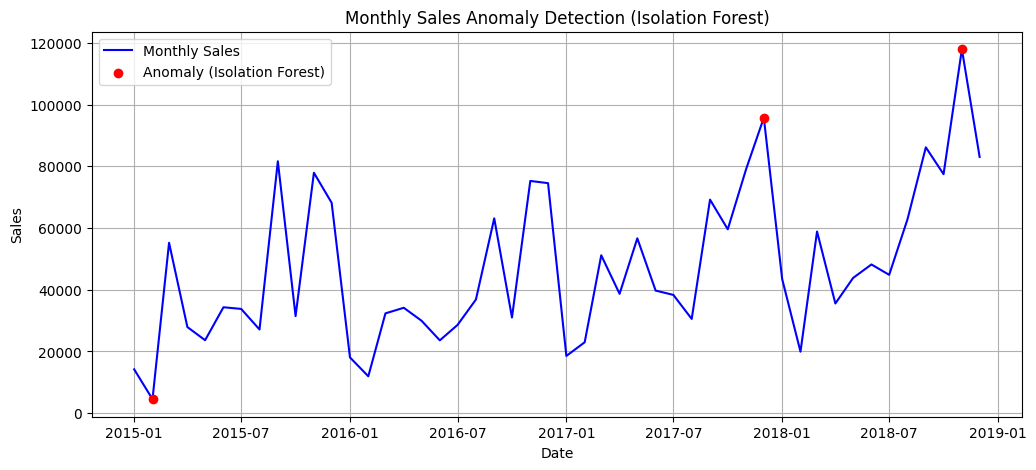

--- Monthly Anomalies Detected ---
                 Sales
ds                    
2015-02-01    4519.892
2017-12-01   95739.121
2018-11-01  117938.155


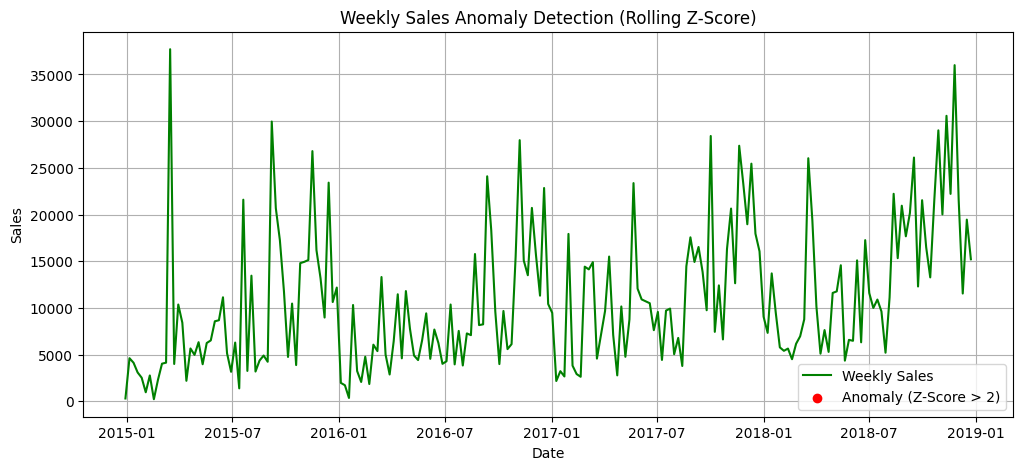


--- Weekly Anomalies Detected ---
Empty DataFrame
Columns: [Sales, z_score]
Index: []


In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly['Sales'], label='Monthly Sales', color='blue')
anomalies_m = df_monthly[df_monthly['is_anomaly']]
plt.scatter(anomalies_m.index, anomalies_m['Sales'], color='red', label='Anomaly (Isolation Forest)', zorder=5)
plt.title('Monthly Sales Anomaly Detection (Isolation Forest)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()



print("--- Monthly Anomalies Detected ---")
print(df_monthly[df_monthly['is_anomaly']][['Sales']])

data['ds_week'] = pd.to_datetime(data['Order Year'].astype(str) + '-' + data['Order Week'].astype(str) + '-1', format='%G-%V-%u')
df_weekly = data.groupby('ds_week')['Sales'].sum().reset_index()
df_weekly.set_index('ds_week', inplace=True)

window = 4
df_weekly['rolling_mean'] = df_weekly['Sales'].rolling(window=window).mean()
df_weekly['rolling_std'] = df_weekly['Sales'].rolling(window=window).std()
df_weekly['z_score'] = (df_weekly['Sales'] - df_weekly['rolling_mean']) / df_weekly['rolling_std']

threshold = 2.0
df_weekly['is_anomaly'] = df_weekly['z_score'].abs() > threshold

plt.figure(figsize=(12, 5))
plt.plot(df_weekly.index, df_weekly['Sales'], label='Weekly Sales', color='green')
anomalies_w = df_weekly[df_weekly['is_anomaly']]
plt.scatter(anomalies_w.index, anomalies_w['Sales'], color='red', label='Anomaly (Z-Score > 2)', zorder=5)
plt.title('Weekly Sales Anomaly Detection (Rolling Z-Score)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Weekly Anomalies Detected ---")
print(df_weekly[df_weekly['is_anomaly']][['Sales', 'z_score']])

In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

product_features = data.groupby('Sub-Category').agg(
    total_sales_volume=('Sales', 'sum'),
    average_order_value=('Sales', 'mean'),
    sales_volatility=('Sales', 'std')
).reset_index()

product_features['sales_volatility'] = product_features['sales_volatility'].fillna(0)

latest_year = data['Order Year'].max()
prior_year = latest_year - 1

sales_latest = data[data['Order Year'] == latest_year].groupby('Sub-Category')['Sales'].sum()
sales_prior = data[data['Order Year'] == prior_year].groupby('Sub-Category')['Sales'].sum()

growth_rate = ((sales_latest - sales_prior) / sales_prior).fillna(0).replace([np.inf, -np.inf], 0)
growth_rate = growth_rate.reset_index().rename(columns={'Sales': 'sales_growth_rate'})

product_features = pd.merge(product_features, growth_rate, on='Sub-Category', how='left').fillna(0)

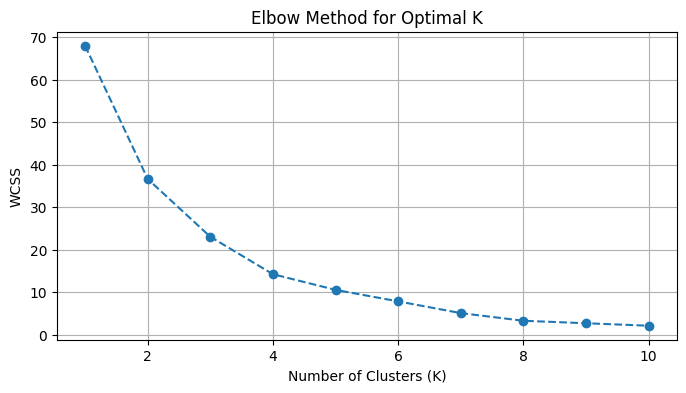

In [39]:
features = ['total_sales_volume', 'sales_growth_rate', 'sales_volatility', 'average_order_value']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(product_features[features])

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [40]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
product_features['Cluster'] = kmeans.fit_predict(scaled_features)

cluster_profiles = product_features.groupby('Cluster')[features].mean()
print("--- Cluster Profile Averages ---")
print(cluster_profiles)

cluster_map = {
    0: 'High Volume, Stable Demand',
    1: 'Low Volume, High Volatility',
    2: 'Growing Demand',
    3: 'Declining Demand'
}
product_features['Demand_Segment'] = product_features['Cluster'].map(cluster_map)

--- Cluster Profile Averages ---
         total_sales_volume  sales_growth_rate  sales_volatility  \
Cluster                                                            
0             167743.362500           0.068413       2990.643794   
1              53715.106140          -0.004979        365.113214   
2              97452.554667           0.438857        249.571209   
3             268189.799750           0.160093        499.765747   

         average_order_value  
Cluster                       
0                1930.716763  
1                 186.153333  
2                 117.533314  
3                 453.885411  


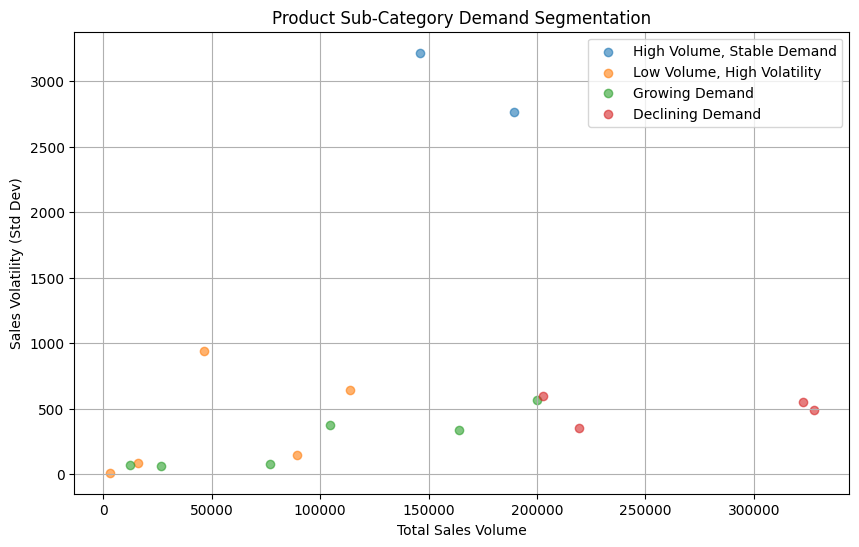

In [41]:
plt.figure(figsize=(10, 6))
for cluster_num in range(optimal_k):
    clustered_data = product_features[product_features['Cluster'] == cluster_num]
    plt.scatter(
        clustered_data['total_sales_volume'], 
        clustered_data['sales_volatility'], 
        label=cluster_map[cluster_num],
        alpha=0.6
    )

plt.title('Product Sub-Category Demand Segmentation')
plt.xlabel('Total Sales Volume')
plt.ylabel('Sales Volatility (Std Dev)')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order Year', 'Order Month', 'Order Week',
       'Order Day', 'Order Season', 'Ship Year', 'Ship Month', 'Ship Week',
       'Ship Day', 'Ship Season', 'monthly sales', 'Weekly sales', 'ds',
       'ds_week'],
      dtype='object')